# The Climate is Changing: How is the Research?

## Exploring Trends in Climate Articles: 2013 to 2023

#### This notebook explores BOW and TFIDF concepts within the corpus.

#### Written by Rafael Alvarado(1) and Caroline Kranefuss(1).

(1) University of Virginia, 2026

### Imports

In [7]:
# General imports
import pandas as pd 
import numpy as np 
from numpy.linalg import norm
import os
import sys

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
import glob
from lxml import etree
from glob import glob
import re
import nltk
nltk_resources = [
    'tokenizers/punkt', 
    'averaged_perceptron_tagger_eng',
    'corpora/stopwords', 
    'help/tagsets'
]

for resource in nltk_resources:
    try:
        nltk.data.find(resource)
    except LookupError:
        nltk.download(resource)
        
        
# ----File Stitching----
# If not in repo home folder, cd back 
if os.path.basename(os.getcwd()) != "evolving_sentiment_climate":
    os.chdir('..')
# If a file is in /sources/, access it by telling the system to look at that path as well as current path
sys.path.append(os.path.join(os.getcwd(), 'sources'))
source_dir = "sources"
source_files_paths = glob(f"{source_dir}/*.xml")
# Same for csvs
sys.path.append(os.path.join(os.getcwd(), 'csvs'))
csvs_dir = "csvs"
csvs_files_paths = glob(f"{csvs_dir}/*.csv")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\student\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [8]:
sns.set_theme(style='darkgrid')

### Defining OHCO

In [9]:
# Define OHCO
OHCO = ['year', 'mth_day', 'doc_id', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:4],
    DOCS = OHCO[:3],
    MTH_DAY = OHCO[:2],
    YEAR = OHCO[:1]
)

bag = 'YEAR' # Goal is to explore by year

### Importing Tables

In [10]:
TOKENS = pd.read_csv("csvs/TOKENS/TOKENS_final.csv").set_index(OHCO).dropna()
LIB = pd.read_csv("csvs/LIB/LIB.csv", sep='|').set_index("year")
VOCAB = pd.read_csv("csvs/VOCAB/VOCAB_pos.csv").set_index("term_str").dropna()

### Creating BOW, DTCM, TFIDF from TOKENS

In [11]:
def computation(TOKENS, VOCAB, bag='YEAR', norm=True):
    # Define BOW by grouping TOKENS by the proper bag and adding counts
    BOW = TOKENS.groupby(bags[bag]+['term_str']).term_str.count().to_frame('n')
    BOW.to_csv(f"csvs/TFIDF/TFIDF_{bag}.csv") 
    
    # Unstack the BOW to create a Document-Term Count Matrix
    DTCM = BOW.n.unstack(fill_value=0)
    DTCM.to_csv(f"csvs/TFIDF/DTCM_{bag}.csv")
    
    # Compute TF, DF, IDF
    TF = compute_tf(DTCM)
    DF = compute_df(DTCM)
    IDF = compute_idf(DTCM, DF)

    # Compute DF-IDF
    DFIDF = DF * IDF 
    
    # Compute and save TFIDF
    TFIDF = compute_tfidf(TF, IDF)
    TFIDF.to_csv(f"csvs/TFIDF/TFIDF_{bag}.csv")
    
    # Normalize if true
    if norm==True:
        TFIDF_norm = compute_tfidf_norm(TFIDF)
        TFIDF_norm.to_csv("csvs/TFIDF/TFIDF_norm.csv")
    
    # Find significant words
    TFIDF_norm_sig = compute_sig(TFIDF_norm)

    # Adjusting existing tables
    VOCAB['df'] = DF
    VOCAB['idf'] = IDF
    VOCAB['dfidf'] = DFIDF
    
    # Adding some other values that I am calculating here but not saving as own table
    VOCAB['dp'] = VOCAB.df / len(VOCAB)
    VOCAB['di'] = np.log2(1/VOCAB.dp)
    VOCAB['dh'] = VOCAB.dp * VOCAB.di
    VOCAB['tfidf_mean'] = TFIDF.mean()
    VOCAB['tfidf_mean_L2'] = TFIDF_norm.mean()

    BOW['df'] = DF
    BOW['df'] = DF
    BOW['idf'] = IDF
    BOW['dfidf'] = DFIDF
    BOW['dp'] = BOW.df / len(BOW)
    BOW['di'] = np.log2(1/BOW.dp)
    BOW['dh'] = BOW.dp * BOW.di
    BOW['tfidf_mean'] = TFIDF.mean()
    BOW['tfidf_mean_L2'] = TFIDF_norm.mean()

    # Some final exports
    BOW.to_csv(f"csvs/TFIDF/BOW_{bag}.csv")
    VOCAB.to_csv(f"csvs/VOCAB/VOCAB_{bag}.csv")

    return BOW, DTCM, TF, DF, IDF, TFIDF, TFIDF_norm, TFIDF_norm_sig


# Helper functions

def compute_tf(DTCM):
    #------------ Compute TF --------------
    # Options are sum, max, log, double_norm, raw, binary, I will use double_norm which requires tf_norm_k
    tf_norm_k = .5          
    gradient_cmap = 'YlGnBu' 
    TF = tf_norm_k + (1 - tf_norm_k) * (DTCM.T / DTCM.T.max(axis=0))
    TF = TF.T
    return TF

def compute_df(DTCM):
    # ------------- Compute DF ------------
    DF = DTCM.astype('bool').sum() 
    return DF

def compute_idf(DTCM, DF):
    # ---------------- Compute IDF -------------
    # Options are standard, max, smooth - I will use smooth, which avoids hard zeros since i only have 3 documetns in the bag level (at Claude's suggestion)
    IDF = np.log2((1 + DTCM.shape[0]) / (1 + DF)) + 1  
    return IDF

def compute_tfidf(TF, IDF):
    # -------------- Compute TFIDF ----------
    TFIDF = TF * IDF
    return TFIDF

def compute_tfidf_norm(TFIDF):
    # ------------ Compute L2 Normalized TF-IDF --------
    # Assist from Claude, my first attempt failed
    TFIDF_norm = TFIDF.div(TFIDF.apply(norm, axis=1), axis=0)
    # Numerator normalizes across rows, denominator is the division of each value by its norm
    return TFIDF_norm

def compute_sig_scratch(TFIDF_norm, q=0.9):
    # ---------- Attempt 1: Words in top 10% of normalized TF-IDF values ----

    # Define a cutoff (top 10%percent)
    cutoff = np.quantile(TFIDF_norm.values, q)

    # Calculate significant words for each year
    sig_2013 = [labels for labels, values in TFIDF_norm.items() if TFIDF_norm.loc[2013, labels] >= cutoff]
    sig_2018 = [labels for labels, values in TFIDF_norm.items() if TFIDF_norm.loc[2018, labels] >= cutoff]
    sig_2023 = [labels for labels, values in TFIDF_norm.items() if TFIDF_norm.loc[2023, labels] >= cutoff]

    # Convert all 3 to sets so unique words can be found
    sig = sig_2013 + sig_2018 + sig_2023
    sig_unique = list(dict.fromkeys(sig))
    sig_unique
    return len(sig_unique)

def compute_sig(TFIDF_norm, q=0.9):
    # ---------- Better attempt: words in top 10% of normalized TF-IDF values ----

    cutoff = np.quantile(TFIDF_norm, q)
    # Make anything less than cutoff NaN
    TFIDF_norm_sig = TFIDF_norm.where(TFIDF_norm >= cutoff)
    # Drop any columns where all values are NaN 
        # Therefore keeping words that are only significant in one year
    TFIDF_norm_sig.dropna(axis=1, how='all', inplace=True)
    # Return (length of df displayed matches above function's list's length)
    return TFIDF_norm_sig

### Computing and Viewing for 'YEAR' Bag

In [12]:
BOW, DTCM, TF, DF, IDF, TFIDF, TFIDF_norm, TFIDF_norm_sig = computation(TOKENS, VOCAB)

In [13]:
BOW.head()

n  df  idf  dfidf        dp         di        dh  tfidf_mean  \
year term_str                                                                  
2013 0         21   3  1.0    3.0  0.000074  13.730364  0.001010    0.502636   
     000        3   3  1.0    3.0  0.000074  13.730364  0.001010    0.500149   
     0000042    1   1  2.0    2.0  0.000025  15.315326  0.000376    1.000067   
     00001      9   3  1.0    3.0  0.000074  13.730364  0.001010    0.500439   
     0000152    1   1  2.0    2.0  0.000025  15.315326  0.000376    1.000067   

               tfidf_mean_L2  
year term_str                 
2013 0              0.003404  
     000            0.003387  
     0000042        0.006773  
     00001          0.003389  
     0000152        0.006773

In [14]:
DTCM.head()

term_str,0,00,000,0000007,000003,0000042,00001,0000152,00002,00003,...,ω,ωarag,ωcal,ϕ,ϕph2oph2o,ϕst,ϵ,ϵerror,ϵn,ϵy
year,,,,,,,,,,,,,,,,,,,,,
2013,21,0,3,0,0,1,9,1,1,0,...,2,0,0,0,0,0,1,1,1,0
2018,80,3,1,0,1,0,8,0,0,0,...,5,35,1,0,0,5,1,0,0,1
2023,69,1,3,1,0,0,2,0,0,4,...,0,0,0,1,1,0,0,0,0,0


In [15]:
TF.head()

term_str,0,00,000,0000007,000003,0000042,00001,0000152,00002,00003,...,ω,ωarag,ωcal,ϕ,ϕph2oph2o,ϕst,ϵ,ϵerror,ϵn,ϵy
year,,,,,,,,,,,,,,,,,,,,,
2013,0.502116,0.500000,0.500302,0.500000,0.500000,0.500101,0.500907,0.500101,0.500101,0.500000,...,0.500201,0.500000,0.500000,0.500000,0.500000,0.500000,0.500101,0.500101,0.500101,0.500000
2018,0.503421,0.500128,0.500043,0.500000,0.500043,0.500000,0.500342,0.500000,0.500000,0.500000,...,0.500214,0.501496,0.500043,0.500000,0.500000,0.500214,0.500043,0.500000,0.500000,0.500043
2023,0.502371,0.500034,0.500103,0.500034,0.500000,0.500000,0.500069,0.500000,0.500000,0.500137,...,0.500000,0.500000,0.500000,0.500034,0.500034,0.500000,0.500000,0.500000,0.500000,0.500000


In [16]:
DF

term_str
0          3
00         2
000        3
0000007    1
000003     1
          ..
ϕst        1
ϵ          2
ϵerror     1
ϵn         1
ϵy         1
Length: 27367, dtype: int64

In [17]:
IDF

term_str
0          1.000000
00         1.415037
000        1.000000
0000007    2.000000
000003     2.000000
             ...   
ϕst        2.000000
ϵ          1.415037
ϵerror     2.000000
ϵn         2.000000
ϵy         2.000000
Length: 27367, dtype: float64

In [18]:
TFIDF

term_str,0,00,000,0000007,000003,0000042,00001,0000152,00002,00003,...,ω,ωarag,ωcal,ϕ,ϕph2oph2o,ϕst,ϵ,ϵerror,ϵn,ϵy
year,,,,,,,,,,,,,,,,,,,,,
2013,0.502116,0.707519,0.500302,1.000000,1.000000,1.000201,0.500907,1.000201,1.000201,1.000000,...,0.707804,1.000000,1.000000,1.000000,1.000000,1.000000,0.707661,1.000201,1.000201,1.000000
2018,0.503421,0.707700,0.500043,1.000000,1.000086,1.000000,0.500342,1.000000,1.000000,1.000000,...,0.707821,1.002993,1.000086,1.000000,1.000000,1.000428,0.707579,1.000000,1.000000,1.000086
2023,0.502371,0.707567,0.500103,1.000069,1.000000,1.000000,0.500069,1.000000,1.000000,1.000275,...,0.707519,1.000000,1.000000,1.000069,1.000069,1.000000,0.707519,1.000000,1.000000,1.000000


In [19]:
TFIDF.mean()

term_str
0          0.502636
00         0.707595
000        0.500149
0000007    1.000023
000003     1.000029
             ...   
ϕst        1.000143
ϵ          0.707586
ϵerror     1.000067
ϵn         1.000067
ϵy         1.000029
Length: 27367, dtype: float64

In [20]:
TFIDF_norm

term_str,0,00,000,0000007,000003,0000042,00001,0000152,00002,00003,...,ω,ωarag,ωcal,ϕ,ϕph2oph2o,ϕst,ϵ,ϵerror,ϵn,ϵy
year,,,,,,,,,,,,,,,,,,,,,
2013,0.003401,0.004792,0.003388,0.006773,0.006773,0.006774,0.003393,0.006774,0.006774,0.006773,...,0.004794,0.006773,0.006773,0.006773,0.006773,0.006773,0.004793,0.006774,0.006774,0.006773
2018,0.003410,0.004793,0.003387,0.006773,0.006773,0.006773,0.003389,0.006773,0.006773,0.006773,...,0.004794,0.006793,0.006773,0.006773,0.006773,0.006776,0.004792,0.006773,0.006773,0.006773
2023,0.003402,0.004792,0.003387,0.006773,0.006773,0.006773,0.003387,0.006773,0.006773,0.006775,...,0.004792,0.006773,0.006773,0.006773,0.006773,0.006773,0.004792,0.006773,0.006773,0.006773


In [21]:
TFIDF_norm_sig

term_str,0000042,0000152,00002,00003,00008,00010,00013,00017,00021,00028,...,μgml,μm,σ2,τi,φst,χ12084,ωarag,ϕst,ϵerror,ϵn
year,,,,,,,,,,,,,,,,,,,,,
2013,0.006774,0.006774,0.006774,NaN,NaN,0.006774,NaN,0.006774,0.006774,0.006774,...,NaN,NaN,0.006774,NaN,0.006782,0.006774,NaN,NaN,0.006774,0.006774
2018,NaN,NaN,NaN,NaN,NaN,NaN,0.006774,NaN,NaN,NaN,...,0.006777,0.006781,NaN,0.006774,NaN,NaN,0.006793,0.006776,NaN,NaN
2023,NaN,NaN,NaN,0.006775,0.006774,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
TFIDF_norm_sig.mean()

term_str
0000042    0.006774
0000152    0.006774
00002      0.006774
00003      0.006775
00008      0.006774
             ...   
χ12084     0.006774
ωarag      0.006793
ϕst        0.006776
ϵerror     0.006774
ϵn         0.006774
Length: 8309, dtype: float64

In [23]:
print(len(VOCAB))

40776


In [24]:
top_tfidf = VOCAB.sort_values("tfidf_mean", ascending=False)
top_tfidf.index.to_list()[0:20]

['blockchain',
 'symbiodiniaceae',
 'exudates',
 'deme',
 'gilli',
 'ncsm',
 'girdled',
 'bee',
 'smart',
 'fox',
 'ai',
 'mouse',
 'tooth',
 'incubations',
 'typhoon',
 'omnh',
 'poultry',
 'mesquite',
 'thicket',
 'dianthus']

In [25]:
top_tfidf_norm = VOCAB.sort_values("tfidf_mean_L2", ascending=False)
top_tfidf_norm.index.to_list()[0:20]

['blockchain',
 'symbiodiniaceae',
 'exudates',
 'deme',
 'gilli',
 'ncsm',
 'girdled',
 'bee',
 'smart',
 'fox',
 'ai',
 'mouse',
 'tooth',
 'incubations',
 'typhoon',
 'omnh',
 'poultry',
 'mesquite',
 'thicket',
 'dianthus']

In [50]:
top_dfidf = VOCAB.sort_values("dfidf", ascending=False)
top_dfidf.index.to_list()[0:50]

['described',
 'especially',
 'level',
 'thus',
 'value',
 'being',
 'example',
 'described',
 'environmental',
 'especially',
 'being',
 'value',
 'thus',
 'example',
 'level',
 'p',
 'example',
 'levels',
 'environmental',
 'environmental',
 'value',
 'levels',
 'likely',
 'thus',
 'level',
 'being',
 'described',
 'likely',
 'especially',
 'likely',
 'p',
 'p',
 'levels',
 'water',
 'research',
 'population',
 'respectively',
 'present',
 'will',
 'respectively',
 'addition',
 'water',
 'addition',
 'any',
 'associated',
 'will',
 'population',
 'research',
 'research',
 'respectively']

In [27]:
def top_years_for_term(term_str):
        top = TFIDF[term_str].to_frame('tfidf_mean').style.bar()
        # Don't sort values since I want to keep the year index in order
        # Don't join with LIB because we only need year, not doc_id or other info
        return top

In [28]:
top_years_for_term('species')

,tfidf_mean
year,
2013,0.546444
2018,0.545151
2023,0.540095


In [29]:
top_years_for_term('soil')

,tfidf_mean
year,
2013,0.518336
2018,0.516975
2023,0.510685


Analysis: 

The TFIDFs for species and for soil are relatively the same, respectively, per year, showing that these are consistently-used terms in climate science, not an exception or development used or phased out year by year. At a very granular level, species and soil are both slightly more important in 2013 and decreases very slightly over the years, which could add credence to my hypothesis and prior findings that climate science has become slightly less biologically-based in favor of more technological, computer/man-made based explorations over the years, but in truth, this difference is too small to make meaningful conclusions or statistically significant ones, especially given that the corpus is relatively small and does not encompass the entirety of climate literature for any given year.


In [30]:
top_years_for_term('technology')

,tfidf_mean
year,
2013,0.500101
2018,0.500214
2023,0.506390


In [31]:
top_years_for_term('blockchain')

,tfidf_mean
year,
2013,1.000000
2018,1.000000
2023,1.025424


Analysis:

Exploring technological words like blockchain and technology yields similar results: a slight addition of credence to my hypothesis and prior findings but mostly statistically insignificant findings/consistency across the years. I am slightly surprised that blockchain has had such a similar TF-IDF in both 2013 and 2023, since it feels a more recent addition to climate science, but perhaps I am underestimating the technological proficiency of the field at the time (in 2013).

In [32]:
top_years_for_term('computer')

,tfidf_mean
year,
2013,0.708517
2018,0.707519
2023,0.708151


In [33]:
top_years_for_term('artificial')

,tfidf_mean
year,
2013,0.707519
2018,0.708063
2023,0.708491


In [34]:
top_years_for_term('intelligence')

,tfidf_mean
year,
2013,0.707519
2018,0.707579
2023,0.707859


In [35]:
top_years_for_term('machine')

,tfidf_mean
year,
2013,0.500201
2018,0.500770
2023,0.500859


In [36]:
top_years_for_term('learning')

,tfidf_mean
year,
2013,0.500101
2018,0.500812
2023,0.501684


In [37]:
top_years_for_term('ai')

,tfidf_mean
year,
2013,1.000000
2018,1.000000
2023,1.008727


In [38]:
top_years_for_term('ml')

,tfidf_mean
year,
2013,0.502418
2018,0.501496
2023,0.501821


Analysis:

I finally explored words like computer, artifical, intelligence, machine, and learning. I did not expect great findings from this search since artifical and intelligence have a vastly different meaning when separate than when together (same for machine and learning) but thought it was worth a peek. Indeed, TF-IDF is nearly identical (often down to the ten-thousandth's place) for all three years. 

A fascinating discovery was the fact that ai and ml still follow this pattern! I am curious about this, but perhaps I am digging for meaning where there is none here - AI and ML have been in development since before 2013 (though it did not become part of the public consciousness until after 2020 as far as I know), and climate science, with its massive datasets and forward-thinking nature, has always well-poised to take advantage of the latest advancements in science and technology alike.

In [39]:
# Claude then suggested finding the terms with the top TF-IDF per year.
def top_terms_for_year(year, n=20):
    return TFIDF.loc[year].sort_values(ascending=False).head(n)

In [40]:
top_terms_for_year(2013)

term_str
exudates          1.015716
deme              1.011888
gilli             1.011283
girdled           1.010075
incubations       1.008463
typhoon           1.008463
dianthus          1.007455
q7q8              1.006851
franciscana       1.006246
tuxtlas           1.005239
xenopus           1.005239
swallows          1.004836
barn              1.004634
girdling          1.004433
jacutinga         1.004231
haemosporidian    1.004231
litterfall        1.004030
comau             1.004030
adelgid           1.003627
exudate           1.003627
Name: 2013, dtype: float64

In [41]:
top_terms_for_year(2018)

term_str
ncsm          1.010433
bee           1.009920
fox           1.008893
mouse         1.008637
tooth         1.008637
omnh          1.008295
mesquite      1.007782
teeth         1.007354
bait          1.007183
plague        1.007183
pallid        1.006841
postmortem    1.006756
asymmetry     1.006670
bees          1.006328
shells        1.006157
bugs          1.005558
lingual       1.005473
mesial        1.005387
herbicide     1.005302
2070          1.005045
Name: 2018, dtype: float64

In [42]:
top_terms_for_year(2023)

term_str
blockchain         1.025424
symbiodiniaceae    1.019446
smart              1.009070
ai                 1.008727
poultry            1.008246
thicket            1.007765
vaccine            1.006940
vaccines           1.006803
2022               1.006459
gsh                1.006322
biochar            1.006047
manaus             1.006047
kunming            1.005978
suzukii            1.005360
iot                1.005291
fireflies          1.004947
transactions       1.004947
transaction        1.004879
xestospongia       1.004879
dpf                1.004879
Name: 2023, dtype: float64

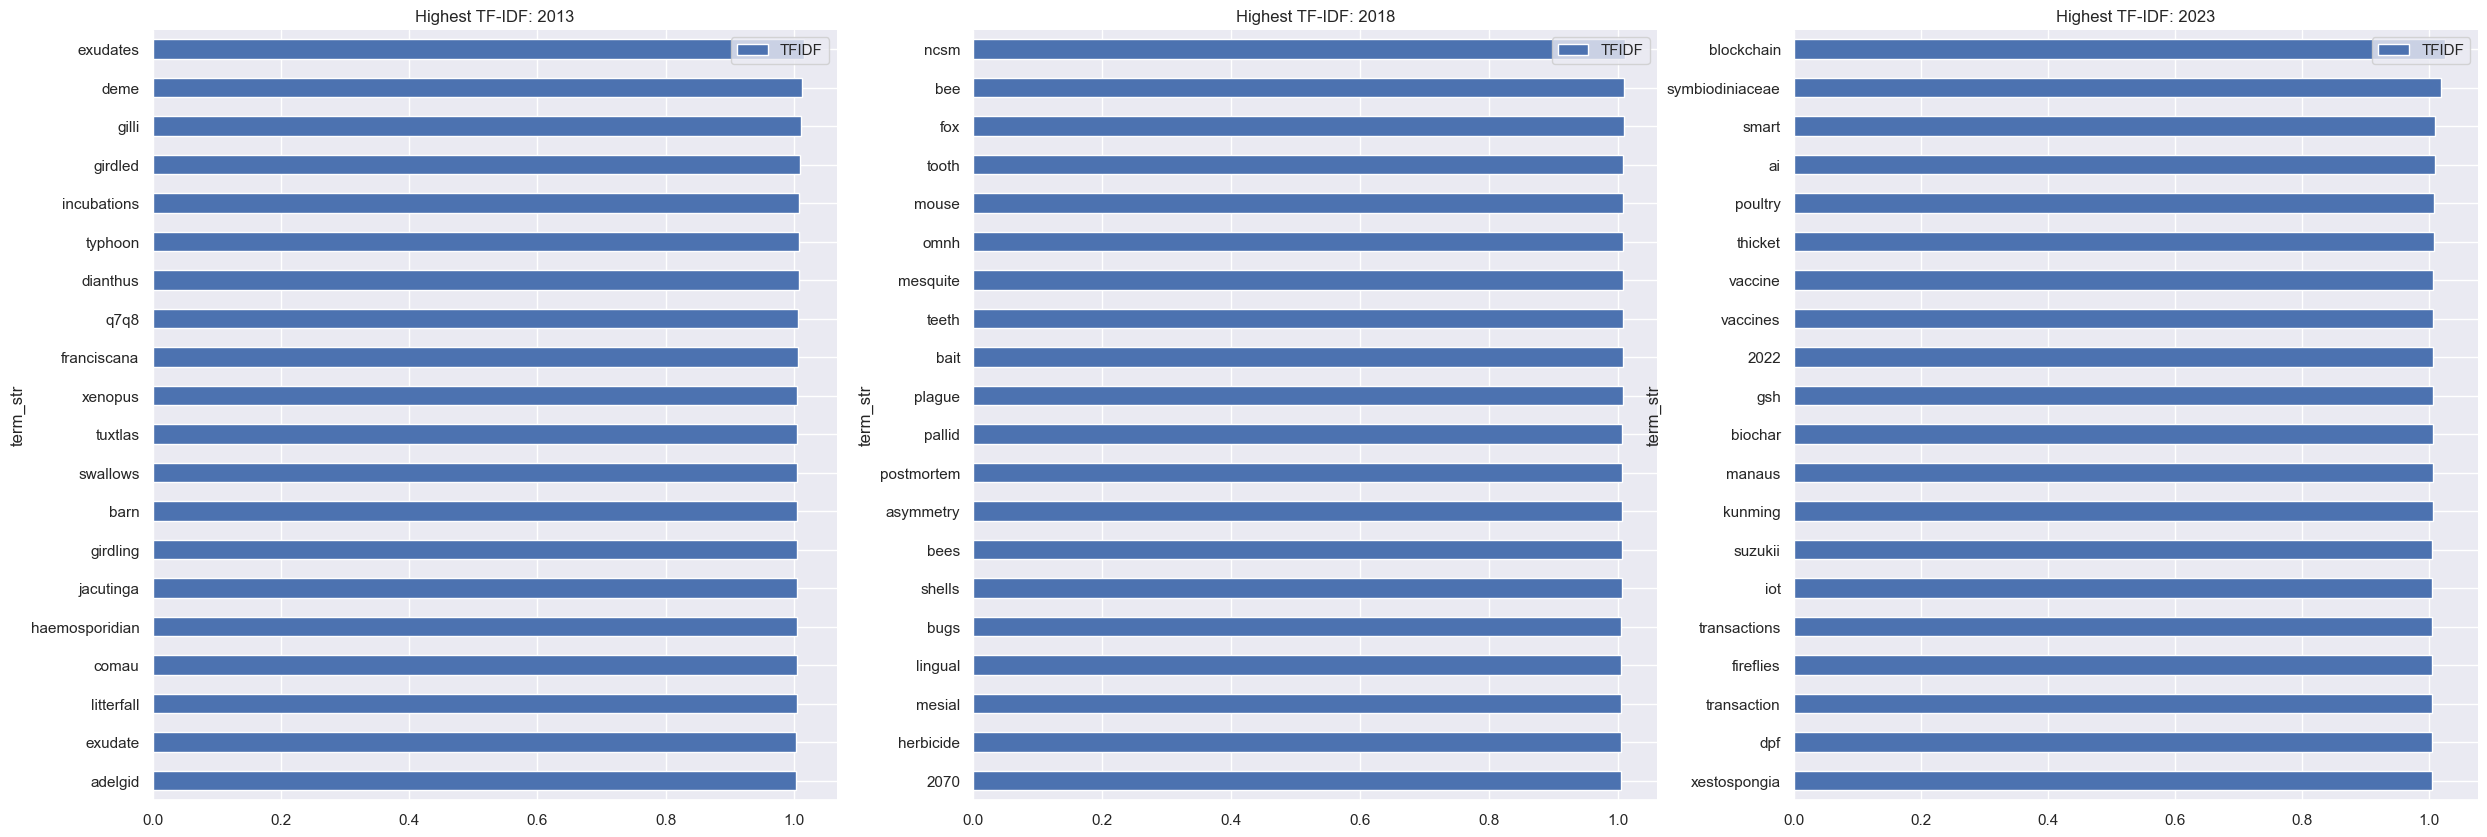

In [43]:
df_2013 = pd.DataFrame(top_terms_for_year(2013))
df_2013.rename(columns={2013: 'TFIDF'}, inplace=True)
df_2018 = pd.DataFrame(top_terms_for_year(2018))
df_2018.rename(columns={2018: 'TFIDF'}, inplace=True)
df_2023 = pd.DataFrame(top_terms_for_year(2023))
df_2023.rename(columns={2023: 'TFIDF'}, inplace=True)

dfs = [df_2013, df_2018, df_2023]

fig, axes = plt.subplots(1,3)
df_2013.sort_values(by='TFIDF').plot.barh(ax=axes[0], figsize=(30,10), title=f"Highest TF-IDF: 2013")
df_2018.sort_values(by='TFIDF').plot.barh(ax=axes[1], figsize=(30,10), title=f"Highest TF-IDF: 2018")
df_2023.sort_values(by='TFIDF').plot.barh(ax=axes[2], figsize=(30,10), title=f"Highest TF-IDF: 2023")
sns.despine()
plt.show()

Analysis:

Scientific names dominate the TF-IDF chart in 2013, while species dominate 2018. This differentiation is very interesting. I wonder at the shift from scientific names to common ones. Perhaps an attempt to make science more accessible? In 2023, we see blockchain, iot (internet of things) and vaccines appear, which, to me is unsurprising given their "buzziness" in the past three years. However, we still see scientific names AND common animal names. I wonder at this reintroduction of scientific names in 2023. As always, future directions include exploration of a larger corpus and more years.


### Computing for 'DOCS' Bag

For use in PCA analysis

In [44]:
BOW_doc, DTCM_doc, TF_doc, DF_doc, IDF_doc, TFIDF_doc, TFIDF_norm_doc, TFIDF_norm_sig_doc = computation(TOKENS, VOCAB, 'DOCS')